# Data Visualisation in Python


### Matplotlib

The primary tool for data visualisation in Python is Matplotlib (so called because it was originally based on visualisation in Matlab).

It has very good documentation and can handle all sorts of plot types (https://matplotlib.org/stable/plot_types/index.html).

### Seaborn

This is another package built on Matplotlib the provides such shortcuts and additional functionality.

Rather that teaching you about the syntax of these libraries, I am going to use them in explaining how to visualise different kinds of variables you will generate in CCL work. You will learn about the packages along the way but to look up the details of the different commands, this chapter provides a nice overview:
https://wesmckinney.com/book/plotting-and-visualization
And the Matplotlib online documentation will tell you the rest.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Continuous Data

In [59]:
rng = np.random.default_rng()
mean = np.array([1.0,1.1])
cov = np.array([[1, 0.25], [0.25, 1]])
X=rng.multivariate_normal(mean, cov, 100)

# Density plots

In [68]:
%matplotlib notebook

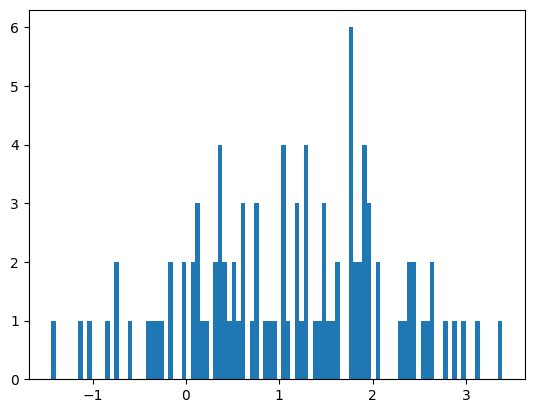

In [5]:
plt.hist(X.T[0],bins=len(set(X.T[0])));

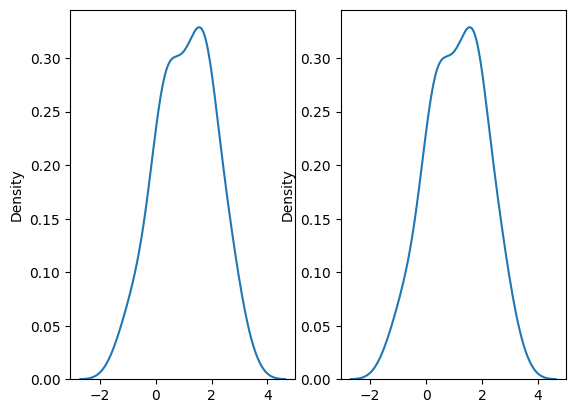

In [37]:
fig, axs = plt.subplots(ncols=2)
sns.kdeplot(X.T[0],ax=axs[0]);
sns.kdeplot(X.T[0],ax=axs[1]);

# Scatter plot

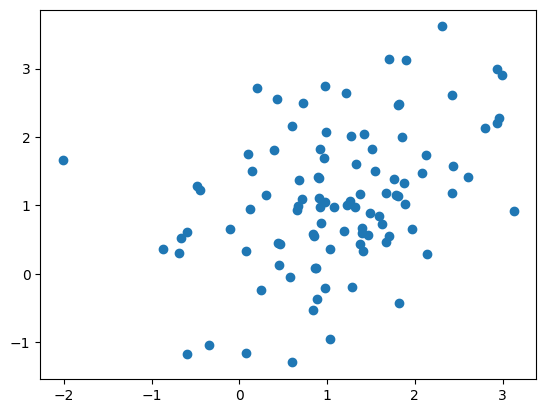

In [48]:
plt.scatter(X.T[0],X.T[1])

# Bar plot

<BarContainer object of 2 artists>

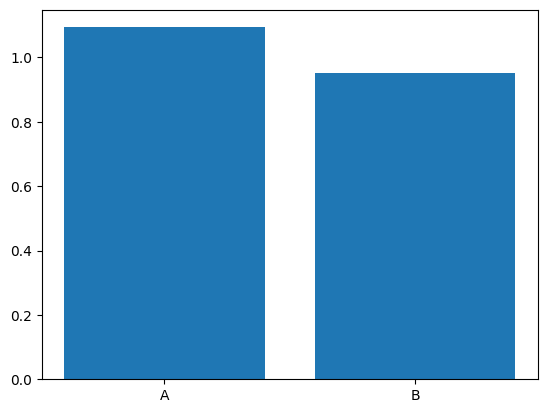

In [26]:
plt.bar(["A","B"], np.mean(X.T,1))


<ErrorbarContainer object of 3 artists>

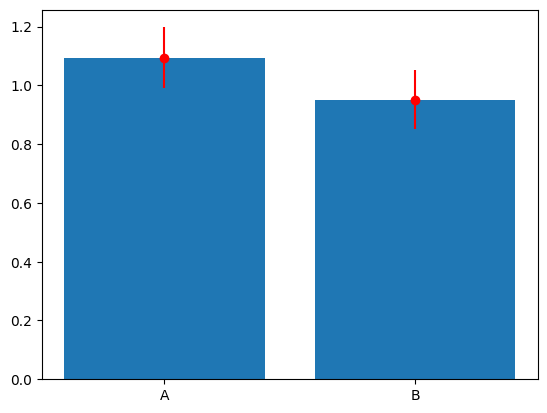

In [28]:
plt.bar(["A","B"], np.mean(X.T,1))
plt.errorbar(["A","B"], np.mean(X.T,1), yerr=np.std(X.T,1)/np.sqrt(len(X.T[0])), fmt="o", color="r")

# Non-normal continuous data

In [60]:
X_skew=np.exp(X)

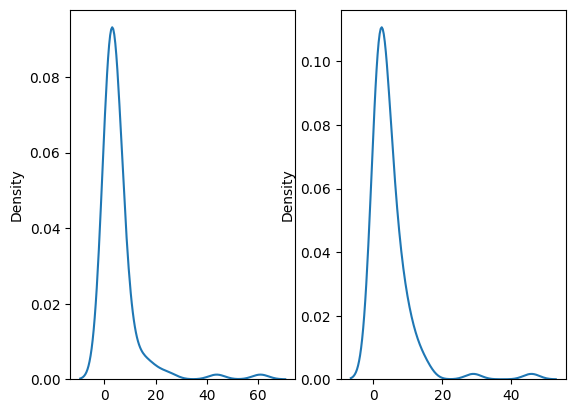

In [62]:
fig, axs = plt.subplots(ncols=2)
sns.kdeplot(X_skew.T[0],ax=axs[0]);
sns.kdeplot(X_skew.T[1],ax=axs[1]);

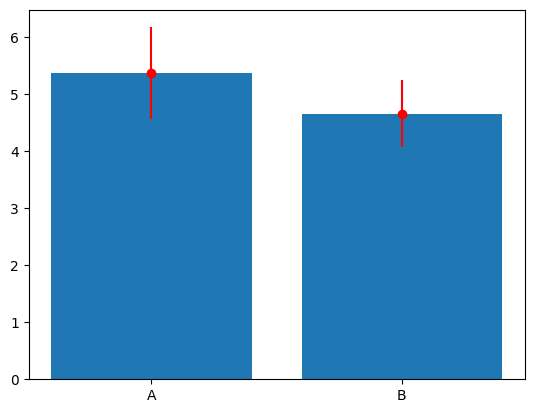

In [63]:
plt.bar(["A","B"], np.mean(X_skew.T,1));
plt.errorbar(["A","B"], np.mean(X_skew.T,1), yerr=np.std(X_skew.T,1)/np.sqrt(len(X_skew.T[0])), fmt="o", color="r");

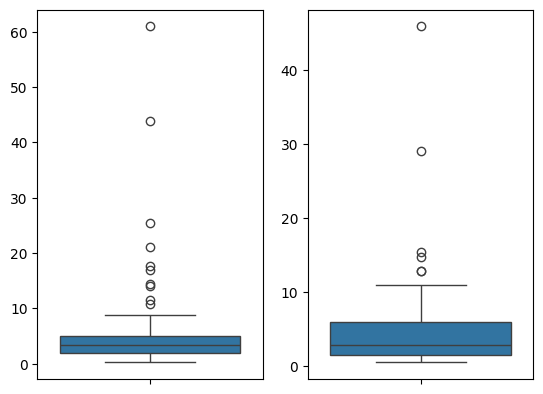

In [64]:
fig, axs = plt.subplots(ncols=2)
sns.boxplot(X_skew.T[0],ax=axs[0]);
sns.boxplot(X_skew.T[1],ax=axs[1]);

# Violin Plots

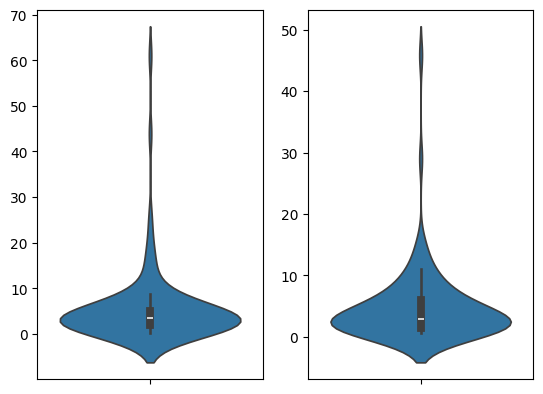

In [65]:
fig, axs = plt.subplots(ncols=2)
sns.violinplot(X_skew.T[0],ax=axs[0]);
sns.violinplot(X_skew.T[1],ax=axs[1]);

# Count Data

In [162]:
import re
# download from from the internt
!wget https://www.gutenberg.org/files/2554/2554-0.txt
# read in the file
f = open('2554-0.txt')
word_frequencies = Counter(f.read()[1:10000].split())
word_frequencies={k: v for k, v in sorted(word_frequencies.items(), key=lambda item: item[1])}
words = list(word_frequencies.keys())
counts = list(word_frequencies.values())
ranks=[]
for count in counts:
     ranks.append(counts.index(count))
ranks=np.max(ranks)-ranks+1

--2026-03-21 15:46:08--  https://www.gutenberg.org/files/2554/2554-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1159923 (1.1M) [text/plain]
Saving to: ‘2554-0.txt.10’

2554-0.txt.10       100%[===================>]   1.11M  7.35MB/s    in 0.2s    

2026-03-21 15:46:09 (7.35 MB/s) - ‘2554-0.txt.10’ saved [1159923/1159923]



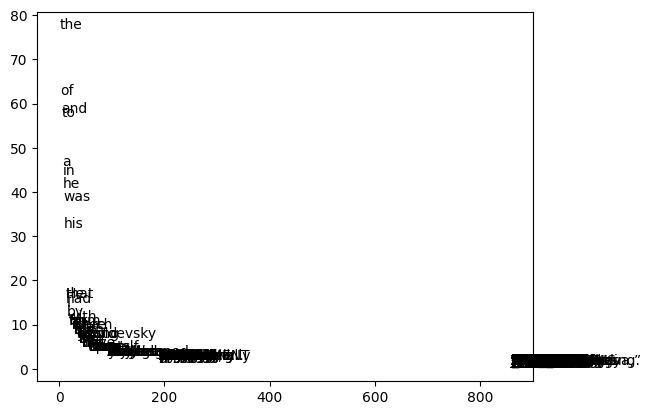

In [166]:
fig, ax = plt.subplots()
ax.scatter(ranks, counts, marker="")

for i, txt in enumerate(words):
    ax.annotate(txt, (ranks[i], counts[i]))

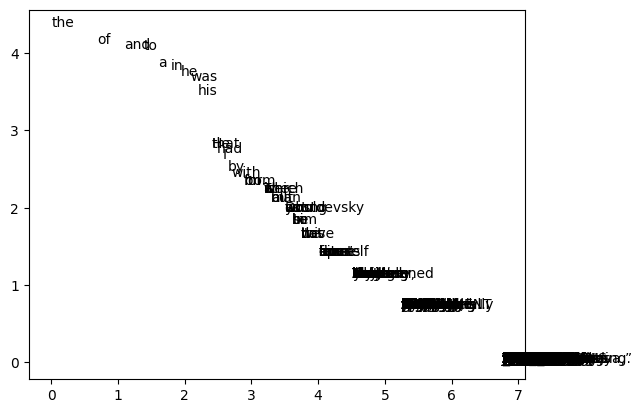

In [167]:
fig, ax = plt.subplots()
ax.scatter(np.log(ranks), np.log(counts), marker="")

for i, txt in enumerate(words):
    ax.annotate(txt, (np.log(ranks[i]), np.log(counts[i])))

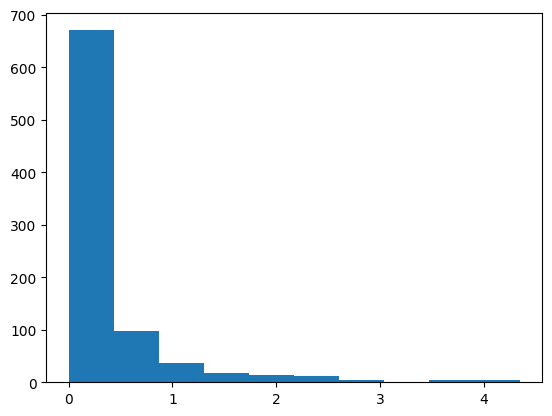

In [170]:
plt.hist(np.log(counts));

# Ordinal Data

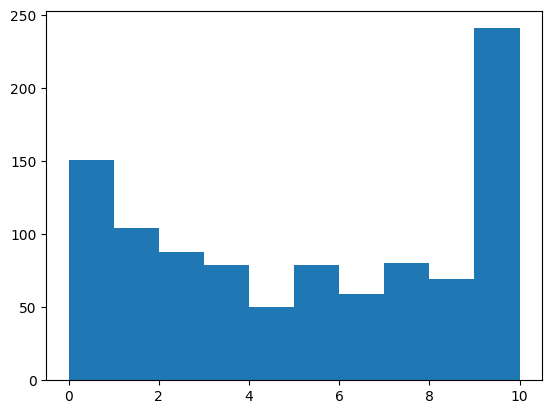

In [183]:
rng = np.random.default_rng()
plt.hist(np.round(rng.beta(a=0.5, b=0.5, size=1000),1)*10);

## Exercises